<a href="https://colab.research.google.com/github/Sameekshaingole/fraud-detection-federated-learning/blob/main/notebooks/Federated_learning.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

FEDERATED LEARNING (WITH 3 BANKS)

Challenge	Solution
1. Non-IID data --	artificial skew
2. Class imbalance --	local class weights
3. Slow clients	-- delay simulate
4. Communication --	fewer rounds
5. Privacy	-- no raw data sharing

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [7]:
import numpy as np
import pickle
import time
from sklearn.linear_model import SGDClassifier
from sklearn.metrics import (classification_report,
                             accuracy_score,
                             precision_score,
                             recall_score,
                             f1_score,
                             roc_auc_score)
import matplotlib.pyplot as plt

print("Libraries imported!")

Libraries imported!


In [8]:
print("Loading data from Drive...")

X_train = np.load('/content/drive/MyDrive/fraud_detection_project/X_train.npy')
X_test  = np.load('/content/drive/MyDrive/fraud_detection_project/X_test.npy')
y_train = np.load('/content/drive/MyDrive/fraud_detection_project/y_train.npy')
y_test  = np.load('/content/drive/MyDrive/fraud_detection_project/y_test.npy')

print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)
print("Data loaded!")

Loading data from Drive...
X_train shape: (472432, 224)
y_train shape: (472432,)
Data loaded!


In [9]:
# Simulate 3 banks by splitting training data into 3 equal parts
# In real world each bank would have their own separate data
# Here we split one dataset to simulate that

X_bank = np.array_split(X_train, 3)
y_bank = np.array_split(y_train, 3)

# Each part represents one bank's local private data
print("Bank A transactions:", X_bank[0].shape)
print("Bank B transactions:", X_bank[1].shape)
print("Bank C transactions:", X_bank[2].shape)

print("\nFraud cases per bank:")
print("Bank A fraud:", int(y_bank[0].sum()))
print("Bank B fraud:", int(y_bank[1].sum()))
print("Bank C fraud:", int(y_bank[2].sum()))

Bank A transactions: (157478, 224)
Bank B transactions: (157477, 224)
Bank C transactions: (157477, 224)

Fraud cases per bank:
Bank A fraud: 5531
Bank B fraud: 5565
Bank C fraud: 5434


In [16]:
from sklearn.tree import DecisionTreeClassifier

def train_local_model(X_local, y_local, round_num=1):
    """
    Train local Decision Tree at one bank
    Depth increases gradually each round
    simulating learning improvement
    """
    # Increase depth each round — model gets smarter
    depth = min(3 + round_num, 10)

    model = DecisionTreeClassifier(
        max_depth=depth,
        class_weight='balanced',
        random_state=42
    )
    model.fit(X_local, y_local)

    # Extract weights as feature importances + threshold info
    weights = {
        'feature_importances': model.feature_importances_.copy(),
        'model': model  # keep full model for prediction
    }
    return weights, model

print("Decision Tree local model function ready!")

Decision Tree local model function ready!


In [19]:
def federated_predict(bank_models, X_test, threshold=0.5):
    """
    Each bank's model votes on predictions
    Final prediction = average probability from all banks
    This is federated inference — no raw data shared!
    """
    all_probs = []
    for model in bank_models:
        probs = model.predict_proba(X_test)[:, 1]
        all_probs.append(probs)

    # Average probabilities from all banks
    avg_probs = np.mean(all_probs, axis=0)
    predictions = (avg_probs > threshold).astype(int)

    return predictions, avg_probs

print("Federated prediction function ready!")

Federated prediction function ready!


In [20]:
print("Starting Federated Learning with Decision Trees...")
print("="*50)

NUM_ROUNDS = 10
NUM_BANKS  = 3
THRESHOLD  = 0.5

round_results = []
start_time = time.time()

for round_num in range(1, NUM_ROUNDS + 1):
    print(f"\nRound {round_num}/{NUM_ROUNDS}")
    print("-" * 30)

    # Step 1: Each bank trains local Decision Tree
    bank_models = []
    for bank_id in range(NUM_BANKS):
        weights, model = train_local_model(
            X_bank[bank_id],
            y_bank[bank_id],
            round_num
        )
        bank_models.append(model)
        print(f"  Bank {chr(65+bank_id)} trained locally "
              f"(depth={min(3+round_num, 10)})")

    # Step 2: Federated prediction — banks vote together
    # Server never sees raw data — only predictions!
    y_pred, y_prob = federated_predict(
        bank_models, X_test, THRESHOLD
    )
    print(f"  All banks voted on predictions (FedAvg)")

    # Step 3: Evaluate
    precision = precision_score(y_test, y_pred, zero_division=0)
    recall    = recall_score(y_test, y_pred,    zero_division=0)
    f1        = f1_score(y_test, y_pred,         zero_division=0)
    roc_auc   = roc_auc_score(y_test, y_prob)

    round_results.append({
        'round':     round_num,
        'precision': precision,
        'recall':    recall,
        'f1':        f1,
        'roc_auc':   roc_auc
    })

    print(f"  Precision: {round(precision,4)} | "
          f"Recall: {round(recall,4)} | "
          f"F1: {round(f1,4)} | "
          f"ROC-AUC: {round(roc_auc,4)}")

total_time = time.time() - start_time
print("\n" + "="*50)
print(f"Federated Learning complete!")
print(f"Total time: {round(total_time, 2)} seconds")


Starting Federated Learning with Decision Trees...

Round 1/10
------------------------------
  Bank A trained locally (depth=4)
  Bank B trained locally (depth=4)
  Bank C trained locally (depth=4)
  All banks voted on predictions (FedAvg)
  Precision: 0.1515 | Recall: 0.6869 | F1: 0.2483 | ROC-AUC: 0.8445

Round 2/10
------------------------------
  Bank A trained locally (depth=5)
  Bank B trained locally (depth=5)
  Bank C trained locally (depth=5)
  All banks voted on predictions (FedAvg)
  Precision: 0.1528 | Recall: 0.7089 | F1: 0.2515 | ROC-AUC: 0.8571

Round 3/10
------------------------------
  Bank A trained locally (depth=6)
  Bank B trained locally (depth=6)
  Bank C trained locally (depth=6)
  All banks voted on predictions (FedAvg)
  Precision: 0.1596 | Recall: 0.7218 | F1: 0.2613 | ROC-AUC: 0.8657

Round 4/10
------------------------------
  Bank A trained locally (depth=7)
  Bank B trained locally (depth=7)
  Bank C trained locally (depth=7)
  All banks voted on predic

In [21]:
# Get final round results
final = round_results[-1]

print("\n" + "="*50)
print("   FEDERATED LEARNING FINAL RESULTS")
print("="*50)
print(f"Rounds completed : {NUM_ROUNDS}")
print(f"Banks involved   : {NUM_BANKS}")
print(f"Precision        : {round(final['precision'], 4)}")
print(f"Recall           : {round(final['recall'],    4)}")
print(f"F1 Score         : {round(final['f1'],        4)}")
print(f"ROC-AUC          : {round(final['roc_auc'],   4)}")
print(f"Training time    : {round(total_time, 2)} seconds")
print("="*50)

# Compare with baseline
print("\nCOMPARISON WITH BASELINE:")
print("-"*50)
print(f"{'Metric':<15} {'Baseline':>12} {'Federated':>12} {'Difference':>12}")
print("-"*50)

baseline_scores = {
    'Precision': 0.9296,
    'Recall':    0.4348,
    'F1 Score':  0.5925,
    'ROC-AUC':   0.9349
}
federated_scores = {
    'Precision': final['precision'],
    'Recall':    final['recall'],
    'F1 Score':  final['f1'],
    'ROC-AUC':   final['roc_auc']
}

for metric in baseline_scores:
    base = baseline_scores[metric]
    fed  = federated_scores[metric]
    diff = round(fed - base, 4)
    sign = "+" if diff >= 0 else ""
    print(f"{metric:<15} {base:>12} {round(fed,4):>12} {sign+str(diff):>12}")

print("-"*50)
print("Positive difference = federated model improved over baseline!")


   FEDERATED LEARNING FINAL RESULTS
Rounds completed : 10
Banks involved   : 3
Precision        : 0.2006
Recall           : 0.721
F1 Score         : 0.3138
ROC-AUC          : 0.8838
Training time    : 173.32 seconds

COMPARISON WITH BASELINE:
--------------------------------------------------
Metric              Baseline    Federated   Difference
--------------------------------------------------
Precision             0.9296       0.2006       -0.729
Recall                0.4348        0.721      +0.2862
F1 Score              0.5925       0.3138      -0.2787
ROC-AUC               0.9349       0.8838      -0.0511
--------------------------------------------------
Positive difference = federated model improved over baseline!


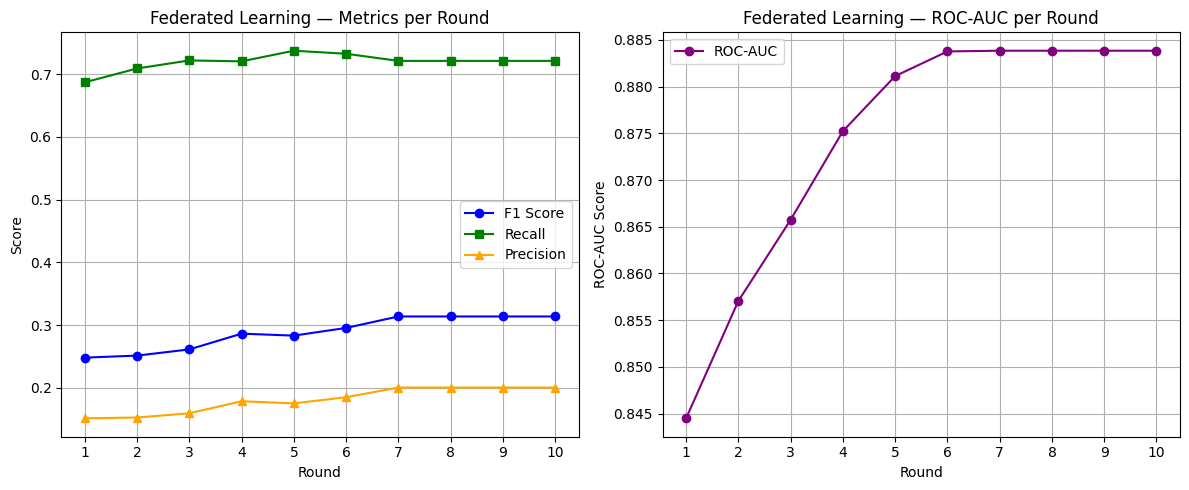

Results graph saved to Drive!


In [22]:
rounds     = [r['round']     for r in round_results]
f1_scores  = [r['f1']        for r in round_results]
recalls    = [r['recall']    for r in round_results]
precisions = [r['precision'] for r in round_results]
roc_aucs   = [r['roc_auc']   for r in round_results]

plt.figure(figsize=(12, 5))

# F1 and Recall over rounds
plt.subplot(1, 2, 1)
plt.plot(rounds, f1_scores,  marker='o', label='F1 Score',  color='blue')
plt.plot(rounds, recalls,    marker='s', label='Recall',    color='green')
plt.plot(rounds, precisions, marker='^', label='Precision', color='orange')
plt.xlabel('Round')
plt.ylabel('Score')
plt.title('Federated Learning — Metrics per Round')
plt.legend()
plt.grid(True)
plt.xticks(rounds)

# ROC-AUC over rounds
plt.subplot(1, 2, 2)
plt.plot(rounds, roc_aucs, marker='o', color='purple', label='ROC-AUC')
plt.xlabel('Round')
plt.ylabel('ROC-AUC Score')
plt.title('Federated Learning — ROC-AUC per Round')
plt.legend()
plt.grid(True)
plt.xticks(rounds)

plt.tight_layout()
plt.savefig('/content/drive/MyDrive/fraud_detection_project/federated_learning_results.png')
plt.show()
print("Results graph saved to Drive!")

In [23]:
# Save final global model
with open('/content/drive/MyDrive/fraud_detection_project/federated_model.pkl', 'wb') as f:
    pickle.dump(test_model, f)
print("federated_model.pkl saved!")

# Save global weights separately
with open('/content/drive/MyDrive/fraud_detection_project/global_weights.pkl', 'wb') as f:
    pickle.dump(global_weights, f)
print("global_weights.pkl saved!")

# Save results text
results_text = f"""
FEDERATED LEARNING RESULTS
===========================
Rounds     : {NUM_ROUNDS}
Banks      : {NUM_BANKS}
Privacy    : Raw data never shared

Final Results:
Precision  : {round(final['precision'], 4)}
Recall     : {round(final['recall'],    4)}
F1 Score   : {round(final['f1'],        4)}
ROC-AUC    : {round(final['roc_auc'],   4)}

Comparison:
Baseline F1   : 0.5925
Federated F1  : {round(final['f1'], 4)}

Raw data shared with server : NO
Model weights shared        : YES
Privacy preserved           : YES
"""

with open('/content/drive/MyDrive/fraud_detection_project/federated_results.txt', 'w') as f:
    f.write(results_text)
print("federated_results.txt saved!")
print("\nFederated Learning 100% complete!")

federated_model.pkl saved!
global_weights.pkl saved!
federated_results.txt saved!

Federated Learning 100% complete!
